## Setup

In [1]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import random 
import copy

le = LabelEncoder()
batch_size=32
X_list = []
y_list = []
subjects_list = []

fold_results = []
fold_conf_mats = []
num_epochs = 60

for i in range(1, 10):
    Xi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    Xi = Xi[:, None, :, :]

    yi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")

    X_list.append(Xi)
    y_list.append(yi)

    subjects_list.append(np.full(len(yi), i))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
subjects = np.concatenate(subjects_list, axis=0)

le = LabelEncoder()
y_cv = le.fit_transform(y).astype(np.int64)
X_cv = X.astype(np.float32)

logo = LeaveOneGroupOut()
k = len(np.unique(subjects))


def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results

In [2]:
#input: (batch, 1, Chans, Samples)

class EEGNetTorch(nn.Module):
    def __init__(self, nb_classes=4, Chans=22, Samples=1001, dropoutRate=0.5, kernLength=125, F1=8, D=2, F2=16, dropoutType="Dropout"):
        super().__init__()

        DropoutLayer = nn.Dropout


        ##################################################Block 1#################################################
        #Conv2D: F1 filters, (1, kernLength) kernel size
        self.conv_temporal = nn.Conv2d(in_channels=1, out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same", bias=False,
        )

        #BatchNormalization
        self.bn1 = nn.BatchNorm2d(F1, eps=1e-3, momentum=0.01)

        # DepthwiseConv2D: kernel size (chans, 1)
        self.conv_spatial = nn.Conv2d(in_channels=F1, out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1, bias=False,
        )

        self.bn2 = nn.BatchNorm2d(F1 * D, eps=1e-3, momentum=0.01)

        #activation

        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))

        self.drop1 = DropoutLayer(dropoutRate)

        ##################################################Block 2#################################################

        #SeparableConv2D: (1,16) kernel size
        self.sepConv = nn.Conv2d(in_channels=F1 * D, out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D, bias=False,
        )

        #SeparableConv2D: F2 filters, 
        self.sep_pointwise = nn.Conv2d(in_channels=F1 * D, out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(F2, eps=1e-3, momentum=0.01)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.drop2 = DropoutLayer(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, Chans, Samples)
            out = self._features(dummy)
            self.flatten_dim = out.flatten(start_dim=1).shape[1]

        self.classifier = nn.Linear(self.flatten_dim, nb_classes)

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)

        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [3]:
batch_size = 32
num_epochs = 60
k = 9
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

nb_classes = len(np.unique(y_cv))
Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []


## Both



================ SCALE 0.5 ================


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(


Early stopping at epoch 41
[[0.60416667 0.20833333 0.0625     0.125     ]
 [0.04166667 0.79861111 0.15972222 0.        ]
 [0.03472222 0.09027778 0.875      0.        ]
 [0.58333333 0.19444444 0.         0.22222222]]

Fold 1 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8672638567386831), 'fmeasure': 0.5987615053918127}
Early stopping at epoch 15
[[0.01388889 0.88194444 0.01388889 0.09027778]
 [0.00694444 0.875      0.01388889 0.10416667]
 [0.00694444 0.9375     0.01388889 0.04166667]
 [0.00694444 0.9375     0.         0.05555556]]

Fold 2 Final Validation -
{'acc': 0.23958333333333334, 'auc': np.float64(0.4935096772119341), 'fmeasure': 0.12933622601991926}
Early stopping at epoch 39
[[0.61111111 0.06944444 0.06944444 0.25      ]
 [0.04861111 0.78472222 0.         0.16666667]
 [0.05555556 0.06944444 0.68055556 0.19444444]
 [0.09027778 0.00694444 0.         0.90277778]]

Fold 3 Final Validation -
{'acc': 0.7447916666666666, 'auc': np.float64(0.9357799639917695), 'fmeasure': 0.746

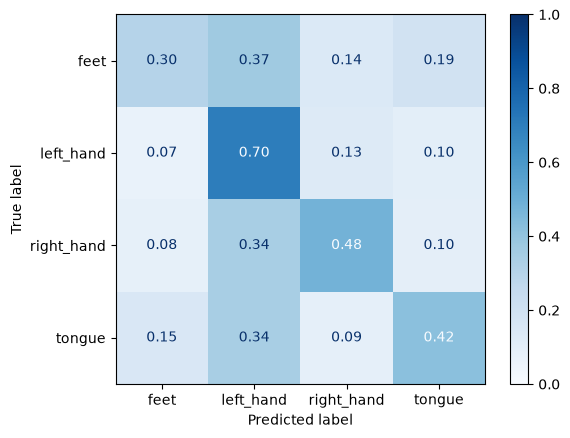



================ SCALE 1.5 ================
Early stopping at epoch 32
[[0.70138889 0.13194444 0.07638889 0.09027778]
 [0.02083333 0.86111111 0.11111111 0.00694444]
 [0.03472222 0.15972222 0.80555556 0.        ]
 [0.72222222 0.13888889 0.00694444 0.13194444]]

Fold 1 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8678948045267489), 'fmeasure': 0.5843965757849108}
Early stopping at epoch 15
[[0.02777778 0.83333333 0.125      0.01388889]
 [0.02083333 0.81944444 0.09027778 0.06944444]
 [0.02777778 0.86111111 0.09722222 0.01388889]
 [0.01388889 0.90277778 0.0625     0.02083333]]

Fold 2 Final Validation -
{'acc': 0.24131944444444445, 'auc': np.float64(0.5180965470679012), 'fmeasure': 0.15017645464053972}
Early stopping at epoch 58
[[0.375      0.07638889 0.14583333 0.40277778]
 [0.02777778 0.59027778 0.02777778 0.35416667]
 [0.01388889 0.04861111 0.70833333 0.22916667]
 [0.01388889 0.00694444 0.         0.97916667]]

Fold 3 Final Validation -
{'acc': 0.6631944444444444, 'auc': np.

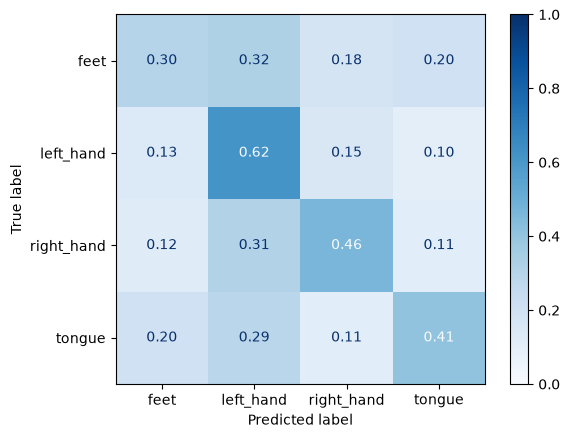



================ SCALE 2.0 ================
Early stopping at epoch 56
[[0.66666667 0.15972222 0.08333333 0.09027778]
 [0.02083333 0.83333333 0.14583333 0.        ]
 [0.03472222 0.08333333 0.88194444 0.        ]
 [0.61805556 0.19444444 0.00694444 0.18055556]]

Fold 1 Final Validation -
{'acc': 0.640625, 'auc': np.float64(0.8755505722736624), 'fmeasure': 0.6051544456310707}
Early stopping at epoch 26
[[0.28472222 0.39583333 0.25694444 0.0625    ]
 [0.20833333 0.51388889 0.27083333 0.00694444]
 [0.22916667 0.32638889 0.43055556 0.01388889]
 [0.20138889 0.52083333 0.25       0.02777778]]

Fold 2 Final Validation -
{'acc': 0.3142361111111111, 'auc': np.float64(0.5997661072530865), 'fmeasure': 0.2771904893894912}
Early stopping at epoch 38
[[0.40277778 0.11805556 0.15277778 0.32638889]
 [0.02777778 0.79861111 0.01388889 0.15972222]
 [0.04166667 0.07638889 0.70833333 0.17361111]
 [0.02083333 0.02083333 0.         0.95833333]]

Fold 3 Final Validation -
{'acc': 0.7170138888888888, 'auc': np

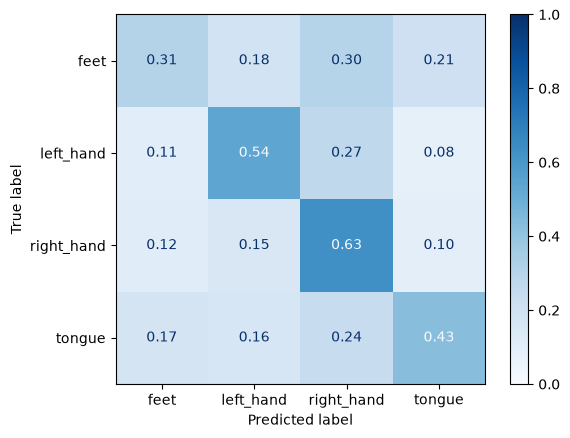



================ SCALE 2.5 ================
Early stopping at epoch 43
[[0.61805556 0.14583333 0.05555556 0.18055556]
 [0.04166667 0.75       0.1875     0.02083333]
 [0.04861111 0.10416667 0.84722222 0.        ]
 [0.47222222 0.18055556 0.00694444 0.34027778]]

Fold 1 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.8725726594650206), 'fmeasure': 0.6260413828431713}
Early stopping at epoch 27
[[0.22222222 0.4375     0.27777778 0.0625    ]
 [0.13888889 0.55555556 0.30555556 0.        ]
 [0.11111111 0.38888889 0.49305556 0.00694444]
 [0.17361111 0.51388889 0.29861111 0.01388889]]

Fold 2 Final Validation -
{'acc': 0.3211805555555556, 'auc': np.float64(0.6106449331275721), 'fmeasure': 0.2736452359149937}
Early stopping at epoch 46
[[0.49305556 0.04166667 0.13194444 0.33333333]
 [0.03472222 0.68055556 0.00694444 0.27777778]
 [0.02777778 0.03472222 0.70138889 0.23611111]
 [0.08333333 0.00694444 0.00694444 0.90277778]]

Fold 3 Final Validation -
{'acc': 0.6944444444444444,

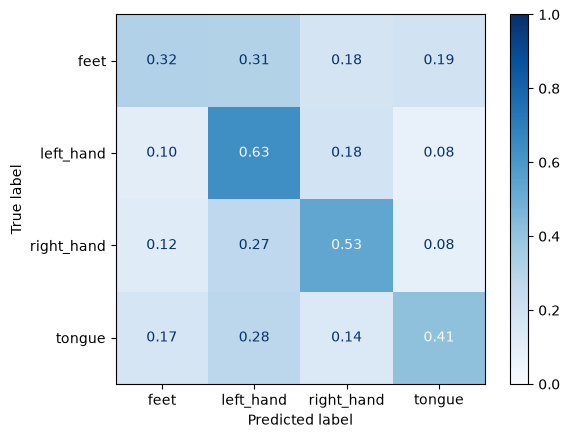

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for scale in [0.5, 1.5, 2.0, 2.5]:

    print(f"\n\n================ SCALE {scale} ================")

    X_scaled = X_cv.copy()

    X_scaled[:, 0, :, :] *= scale

    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(logo.split(X_scaled, y_cv, groups=subjects), start=1):

        X_tr, X_va = X_scaled[train_idx], X_scaled[valid_idx]
        y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
        print(cm)
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)


    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)


    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        im_kw={"vmin": 0, "vmax": 1},
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm

In [ ]:
cm=(cm1+cm2+cm3+cm4)/4

## Train alone



================ SCALE 0.5 ================
Early stopping at epoch 24
[[0.32638889 0.10416667 0.02083333 0.54861111]
 [0.01388889 0.89583333 0.04861111 0.04166667]
 [0.02777778 0.5        0.45138889 0.02083333]
 [0.30555556 0.11805556 0.         0.57638889]]

Fold 1 Final Validation -
{'acc': 0.5625, 'auc': np.float64(0.8533548739711935), 'fmeasure': 0.5487457648305321}
Early stopping at epoch 15
[[0.04861111 0.54861111 0.02083333 0.38194444]
 [0.02083333 0.77777778 0.00694444 0.19444444]
 [0.02777778 0.72222222 0.02083333 0.22916667]
 [0.01388889 0.6875     0.02083333 0.27777778]]

Fold 2 Final Validation -
{'acc': 0.28125, 'auc': np.float64(0.5580954218106996), 'fmeasure': 0.20237114573778142}
Early stopping at epoch 30
[[0.63888889 0.08333333 0.06944444 0.20833333]
 [0.22222222 0.60416667 0.00694444 0.16666667]
 [0.26388889 0.09027778 0.54166667 0.10416667]
 [0.47916667 0.02083333 0.00694444 0.49305556]]

Fold 3 Final Validation -
{'acc': 0.5694444444444444, 'auc': np.float64(0.8

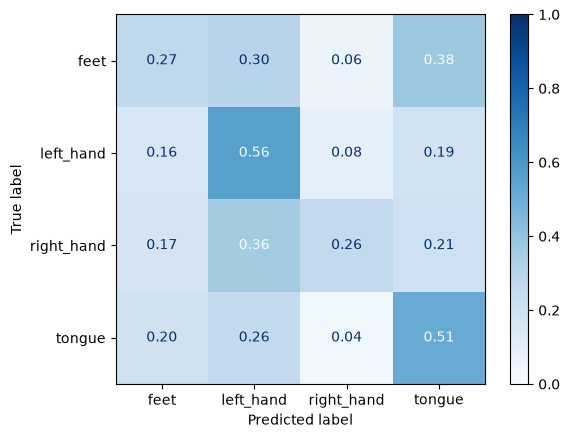



================ SCALE 1.5 ================
Early stopping at epoch 28
[[0.29861111 0.28472222 0.15972222 0.25694444]
 [0.         0.73611111 0.25694444 0.00694444]
 [0.         0.11805556 0.88194444 0.        ]
 [0.1875     0.27777778 0.03472222 0.5       ]]

Fold 1 Final Validation -
{'acc': 0.6041666666666666, 'auc': np.float64(0.8647641782407408), 'fmeasure': 0.583486518997001}
Early stopping at epoch 24
[[0.30555556 0.48611111 0.1875     0.02083333]
 [0.21527778 0.58333333 0.20138889 0.        ]
 [0.30555556 0.36805556 0.32638889 0.        ]
 [0.24305556 0.52083333 0.22222222 0.01388889]]

Fold 2 Final Validation -
{'acc': 0.3072916666666667, 'auc': np.float64(0.5506446116255144), 'fmeasure': 0.2633578527284561}
Early stopping at epoch 27
[[0.27777778 0.10416667 0.5        0.11805556]
 [0.08333333 0.65972222 0.18055556 0.07638889]
 [0.02777778 0.02777778 0.94444444 0.        ]
 [0.28472222 0.01388889 0.125      0.57638889]]

Fold 3 Final Validation -
{'acc': 0.6145833333333334, 

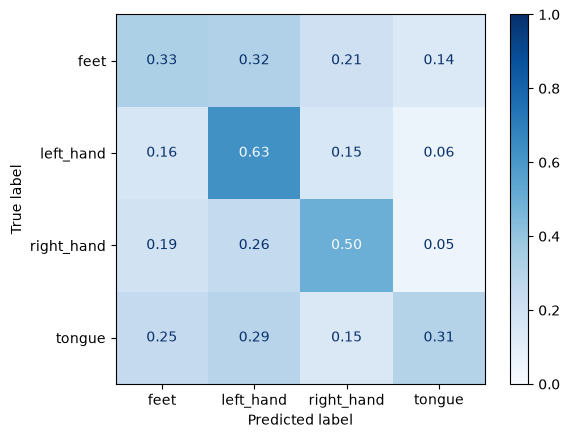



================ SCALE 2.0 ================
Early stopping at epoch 24
[[0.25       0.39583333 0.09027778 0.26388889]
 [0.         0.875      0.125      0.        ]
 [0.         0.26388889 0.73611111 0.        ]
 [0.21527778 0.27777778 0.01388889 0.49305556]]

Fold 1 Final Validation -
{'acc': 0.5885416666666666, 'auc': np.float64(0.8678425604423868), 'fmeasure': 0.5684589699046532}
Early stopping at epoch 15
[[0.         0.53472222 0.46527778 0.        ]
 [0.         0.48611111 0.51388889 0.        ]
 [0.         0.51388889 0.48611111 0.        ]
 [0.         0.65972222 0.34027778 0.        ]]

Fold 2 Final Validation -
{'acc': 0.24305555555555555, 'auc': np.float64(0.5091186021090536), 'fmeasure': 0.16272061988807576}
Early stopping at epoch 21
[[0.36805556 0.29166667 0.31944444 0.02083333]
 [0.05555556 0.84722222 0.06944444 0.02777778]
 [0.04861111 0.11111111 0.84027778 0.        ]
 [0.31944444 0.13194444 0.09722222 0.45138889]]

Fold 3 Final Validation -
{'acc': 0.626736111111111

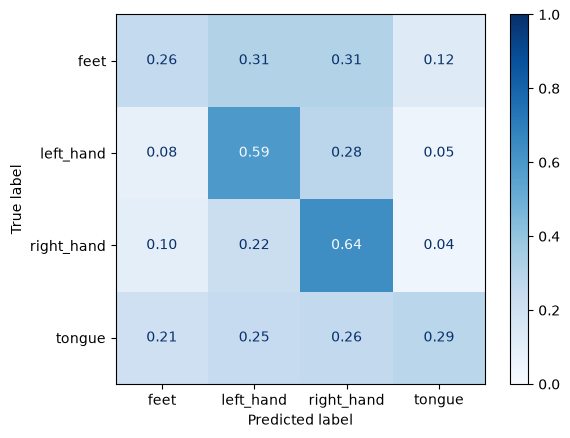



================ SCALE 2.5 ================
Early stopping at epoch 33
[[0.26388889 0.05555556 0.53472222 0.14583333]
 [0.05555556 0.1875     0.75694444 0.        ]
 [0.         0.         1.         0.        ]
 [0.34722222 0.09722222 0.20833333 0.34722222]]

Fold 1 Final Validation -
{'acc': 0.4496527777777778, 'auc': np.float64(0.8295114776234568), 'fmeasure': 0.4082510658197488}
Early stopping at epoch 22
[[0.00694444 0.88194444 0.         0.11111111]
 [0.         0.97916667 0.00694444 0.01388889]
 [0.         0.92361111 0.01388889 0.0625    ]
 [0.01388889 0.91666667 0.         0.06944444]]

Fold 2 Final Validation -
{'acc': 0.2673611111111111, 'auc': np.float64(0.5619554558899177), 'fmeasure': 0.1419642846733673}
Early stopping at epoch 44
[[0.24305556 0.11805556 0.52083333 0.11805556]
 [0.02777778 0.58333333 0.3125     0.07638889]
 [0.03472222 0.02083333 0.93055556 0.01388889]
 [0.11805556 0.07638889 0.3125     0.49305556]]

Fold 3 Final Validation -
{'acc': 0.5625, 'auc': np.f

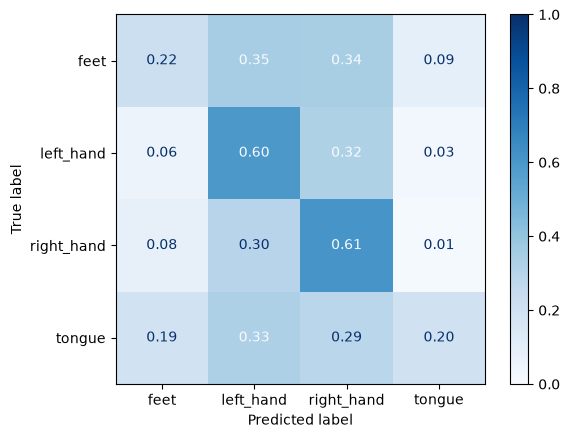

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for scale in [0.5, 1.5, 2.0, 2.5]:

    print(f"\n\n================ SCALE {scale} ================")


    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(
    logo.split(X_cv, y_cv, groups=subjects),
    start=1
    ):
        X_tr = X_cv[train_idx].copy()
        X_va = X_cv[valid_idx].copy()

        y_tr = y_cv[train_idx]
        y_va = y_cv[valid_idx]

        X_tr[:, 0, :, :] *= scale

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
        nb_classes=4,
        Chans=22,
        Samples=1001,
        kernLength=250,
        F1=8,
        D=1,
        F2=16,
        dropoutRate=0.25550867989537085,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0026353430928847833, 
            weight_decay=1.4077242503865625e-06
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
        print(cm)
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)


    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)


    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        im_kw={"vmin": 0, "vmax": 1},
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm

## test



================ SCALE 0.5 ================
[[0.08333333 0.39583333 0.23611111 0.28472222]
 [0.         0.63194444 0.35416667 0.01388889]
 [0.         0.00694444 0.99305556 0.        ]
 [0.06944444 0.4375     0.07638889 0.41666667]]

Fold 1 Final Validation -
{'acc': 0.53125, 'auc': np.float64(0.8443086098251028), 'fmeasure': 0.47209513006289006}
Early stopping at epoch 15
[[0.         0.98611111 0.01388889 0.        ]
 [0.         0.97916667 0.02083333 0.        ]
 [0.         0.98611111 0.01388889 0.        ]
 [0.         0.97222222 0.02777778 0.        ]]

Fold 2 Final Validation -
{'acc': 0.2482638888888889, 'auc': np.float64(0.5047140239197531), 'fmeasure': 0.1058874380090086}
Early stopping at epoch 39
[[0.01388889 0.21527778 0.36111111 0.40972222]
 [0.         0.90277778 0.01388889 0.08333333]
 [0.         0.04861111 0.90277778 0.04861111]
 [0.         0.03472222 0.02777778 0.9375    ]]

Fold 3 Final Validation -
{'acc': 0.6892361111111112, 'auc': np.float64(0.9195240162037036

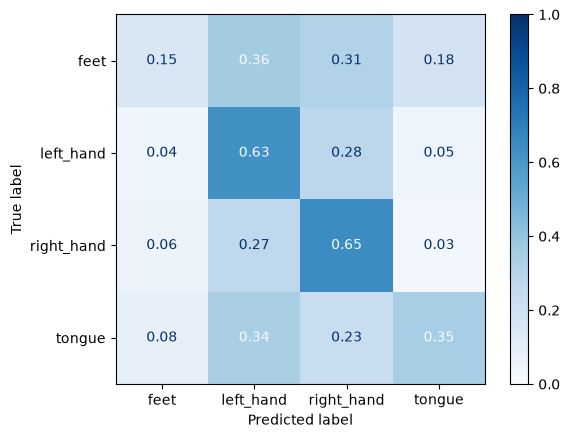



================ SCALE 1.5 ================
[[0.57638889 0.15277778 0.04166667 0.22916667]
 [0.01388889 0.86111111 0.10416667 0.02083333]
 [0.03472222 0.20833333 0.75       0.00694444]
 [0.42361111 0.19444444 0.00694444 0.375     ]]

Fold 1 Final Validation -
{'acc': 0.640625, 'auc': np.float64(0.8781587577160493), 'fmeasure': 0.6308127946340043}
Early stopping at epoch 16
[[0.25       0.22222222 0.34722222 0.18055556]
 [0.13888889 0.34027778 0.45138889 0.06944444]
 [0.15972222 0.28472222 0.45138889 0.10416667]
 [0.125      0.27083333 0.44444444 0.15972222]]

Fold 2 Final Validation -
{'acc': 0.3003472222222222, 'auc': np.float64(0.5525012860082305), 'fmeasure': 0.29153184570887675}
Early stopping at epoch 42
[[0.63194444 0.06944444 0.05555556 0.24305556]
 [0.07638889 0.65972222 0.01388889 0.25      ]
 [0.07638889 0.05555556 0.63194444 0.23611111]
 [0.06944444 0.01388889 0.         0.91666667]]

Fold 3 Final Validation -
{'acc': 0.7100694444444444, 'auc': np.float64(0.929808063271604

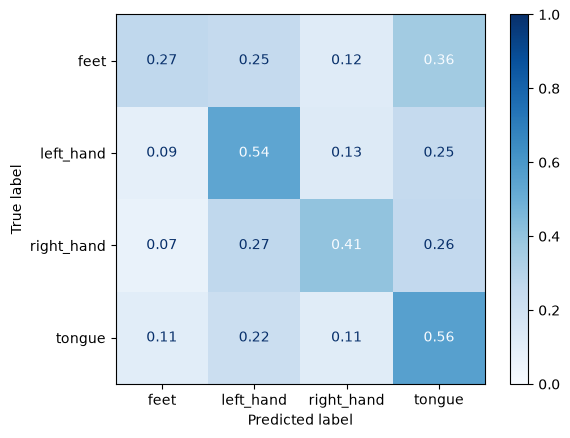



================ SCALE 2.0 ================
Early stopping at epoch 23
[[0.56944444 0.10416667 0.00694444 0.31944444]
 [0.18055556 0.77777778 0.         0.04166667]
 [0.49305556 0.31944444 0.13888889 0.04861111]
 [0.38888889 0.13888889 0.         0.47222222]]

Fold 1 Final Validation -
{'acc': 0.4895833333333333, 'auc': np.float64(0.8376334233539096), 'fmeasure': 0.46041884156859847}
Early stopping at epoch 17
[[0.08333333 0.20833333 0.04166667 0.66666667]
 [0.0625     0.48611111 0.05555556 0.39583333]
 [0.09027778 0.30555556 0.08333333 0.52083333]
 [0.07638889 0.39583333 0.0625     0.46527778]]

Fold 2 Final Validation -
{'acc': 0.2795138888888889, 'auc': np.float64(0.5723259066358025), 'fmeasure': 0.24302465516958677}
Early stopping at epoch 47
[[0.66666667 0.05555556 0.06944444 0.20833333]
 [0.13888889 0.625      0.00694444 0.22916667]
 [0.16666667 0.06944444 0.58333333 0.18055556]
 [0.11805556 0.02083333 0.         0.86111111]]

Fold 3 Final Validation -
{'acc': 0.684027777777777

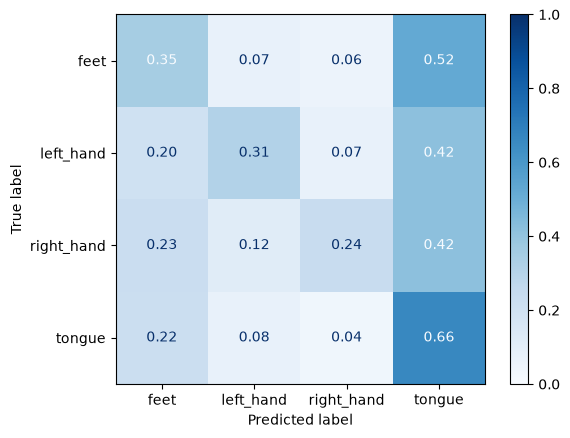



================ SCALE 2.5 ================
Early stopping at epoch 36
[[0.79166667 0.04166667 0.02083333 0.14583333]
 [0.30555556 0.64583333 0.03472222 0.01388889]
 [0.375      0.13194444 0.49305556 0.        ]
 [0.60416667 0.10416667 0.         0.29166667]]

Fold 1 Final Validation -
{'acc': 0.5555555555555556, 'auc': np.float64(0.8605886702674898), 'fmeasure': 0.5562095016702743}
Early stopping at epoch 15
[[0.02777778 0.05555556 0.         0.91666667]
 [0.02777778 0.11111111 0.         0.86111111]
 [0.04861111 0.05555556 0.         0.89583333]
 [0.04861111 0.05555556 0.         0.89583333]]

Fold 2 Final Validation -
{'acc': 0.2586805555555556, 'auc': np.float64(0.5185868377057613), 'fmeasure': 0.15355076975007204}
Early stopping at epoch 15
[[0.00694444 0.01388889 0.         0.97916667]
 [0.01388889 0.03472222 0.         0.95138889]
 [0.00694444 0.01388889 0.         0.97916667]
 [0.         0.         0.         1.        ]]

Fold 3 Final Validation -
{'acc': 0.2604166666666667

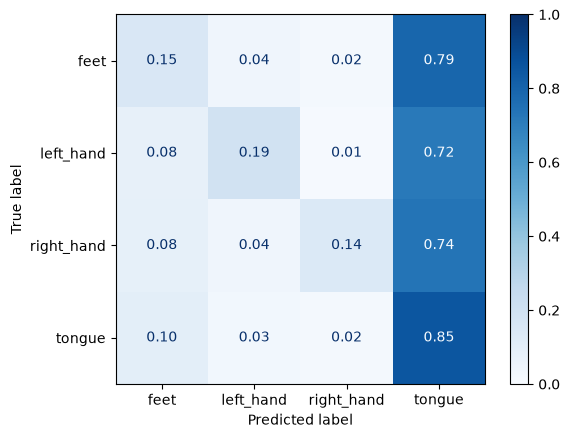

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for scale in [0.5, 1.5, 2.0, 2.5]:

    print(f"\n\n================ SCALE {scale} ================")


    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(
    logo.split(X_cv, y_cv, groups=subjects),
    start=1
    ):
        X_tr = X_cv[train_idx].copy()
        X_va = X_cv[valid_idx].copy()

        y_tr = y_cv[train_idx]
        y_va = y_cv[valid_idx]

        X_va[:, 0, :, :] *= scale

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
        print(cm)
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)


    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)


    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        im_kw={"vmin": 0, "vmax": 1},
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm